# Learning Objectives

After reading this notebook, students will be able to:


- Formally define the concept of resolution, pixels.
- Compare the image size with resolution.
- Explain the image resizing from preserving and non- preserving the aspect ratio.
- Understand the concept of Upscale using padding.
- Implement OpenCV Resize function in the image.

## Image Resolution

Image resolution contains the detail of the image, i.e., the number of pixels or dots. Pixels are the picture element of the digital image. The term pix refers to the picture and el as an element.
There are two types of resolution you want to look up in the image.

* Spatial resolution

  Spatial resolution measures the small details in the image. You are more familiar with dots per inch (dpi), which gives the measure of spatial resolution.

* Intensity resolution

  Intensity resolution measures the change in the small details in the image. The intensity resolution gives the range value for each pixel. In most cases, the intensity of 8 bits means pixels hold value from 0 to 255. In some cases, it can go to 16 bits; however, 32 bits are very rare.



## Image Resizing

The image size is determined by the resolution and is multiplied by the width and height of an image. We can change the size of the image either by adding or subtracting pixels. The changing dimension i.e., height or width or both of an image, is known as image resizing. OpenCV provides cv2.resize() function to resize the image. The short description of the cv2.resize parameter is;

1. `src` is the first parameter that represents the source of the input image.

2. `dsize` is the desired dimension of the image representing its height and width.

3. `fx` and `fy` are the third and fourth parameters representing the scale factor along the horizontal and vertical axis. These parameters are optional.

4. `interpolation` is the optional flag of any methods like `INTER_NEAREST` , `INTER_LINEAR`, `INTER_AREA`, `INTER_CUBIC`.







<figure>
<center>
<!-- <img src='http://bigwww.epfl.ch/algorithms/ijplugins/resize/meta/splash.png'/>
<Figcaption> Figure 1: Resizing of an image (src: <a href='http://bigwww.epfl.ch/algorithms/ijplugins/resize/meta/splash.png'> link</a>) -->

<img src='https://i.postimg.cc/XqXmNHYL/image.png'/>
<Figcaption> Figure 1: Resizing of an image (src: <a href='http://bigwww.epfl.ch/algorithms/ijplugins/resize/meta/splash.png'> link</a>)

</Figcaption>
</center>
</figure>

In the above figure, the images resizing from a larger size to a smaller size and then again resizing to a larger size. The shape of the image changes and also the resolution. Image resizing can be done in several ways and are categorized as,

1. Preserve the aspect ratio
  - Downsampling
  - Upsampling

2. Do not preserve the aspect ratio
  - Resize only the width
  - Resize only the height
  - Resize to specific height and width

## Resample Image

The image changes the pixels, either adding or subtracting pixel is formally known as upsampling or downsampling.

### DownSampling

<figure>
<center>
<!-- <img src='https://doc.google.com/a/fusemachines.com/uc?export=download&id=157lZrlOk-lBX2yQNQPgKBaqNp58Sr6qc'/> -->

<img src="https://i.postimg.cc/kg7ZBgGD/image.png"/>

<Figcaption> Figure 2: Image Downscaling</Figcaption>
</center>
</figure>

The process of reducing the size of the image to smaller dimensions is known as downsampling. Downsampling makes the data more manageable size and reduces the storage size of data.

When we resize the image to a smaller size, we throw the information present in the image. This means you are resampling the image at a smaller rate.

### Upsampling

<figure>
<center>
<!-- <img src='https://doc.google.com/a/fusemachines.com/uc?export=download&id=1htboo-UMqG3PVnDHHNz0u-ACreCtW1NR'/> -->
<img src="https://i.postimg.cc/d3m6YG86/image.png"/>
<Figcaption> Figure 3: Image Upscaling</Figcaption>
</center>
</figure>

The process of increasing the size of the image is known as upsampling. Upsampling can be used in many cases, such as in GANs(Generative Adversarial Network), where the main goal is to construct the mimicking image close to the ground truth image.

As we resize the image to a larger size, we add the information that wasn't previously present in the image. As a result of this, we can say it is a way to resample the image at a higher rate.

Both of these actions affect the image's resolution because you may see distortion when resizing to a smaller size and pixelation when resizing to a larger size.
While ensuring these two operations, the main motive is to preserve the image's quality as far as we can. It is easy to downsample, as we are removing the information, while in upsampling, it is hard to add the relavant information.There are various things that nedds to be taken into account:
- Total image size
- Neighboring pixels
- Image histogram and so on.

So, there is no concrete way to define this. here we simply use interpolation.

**Note: Upsampling is a hard task and not trivial.**

## Implementation I

### 1. Preserve the aspect ratio


In [1]:
#Importing library
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [2]:
#Load the input image
!wget -q --no-check-certificate 'https://docs.google.com/uc?export=download&id=14gRn4ABpTkU18FsK3tvVfrM6CsKw_-ZQ' -O sample.png

Original Dimension : (3456, 5184, 3)


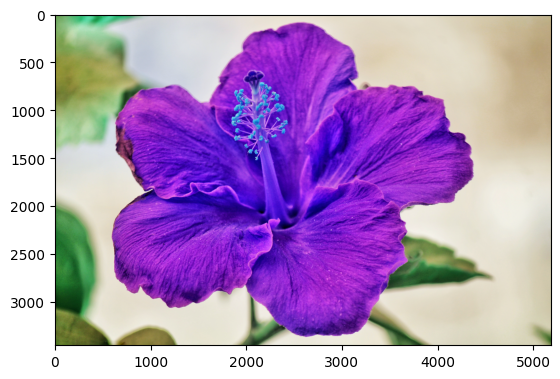

In [3]:
image = cv2.imread('sample.png', cv2.COLOR_BGR2RGB)
plt.imshow(image)
print('Original Dimension :', image.shape)


The (3456, 5184, 3) is the dimension of original image represent height, weight and number of channels.

### 1. Preserve the aspect ratio



#### Downscale with resize()

In [4]:
# percent of original size
scale_percent = 60
height = int(image.shape[0] * scale_percent / 100)
width = int(image.shape[1] * scale_percent / 100)
dimension = (width, height)



Resized Dimensions :  (2073, 3110, 3)


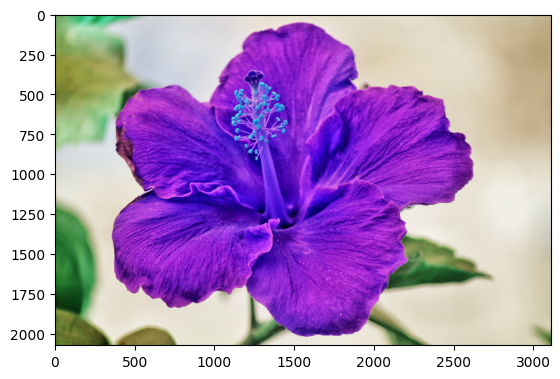

In [5]:
# resize image
down_resized = cv2.resize(image, dimension, interpolation = cv2.INTER_AREA)
plt.imshow(down_resized)
print('Resized Dimensions : ',down_resized.shape)

The orginal image having dimension (3456, 5184, 3) is resized to  (2073, 3110, 3) using cv2.resize() function.

#### Upscale with resize()

In [6]:
# percent of original size
up_scale_percent = 220
height1 = int(image.shape[0] * up_scale_percent / 100)
width1 = int(image.shape[1] * up_scale_percent / 100)
dimension1 = (width1, height1)

Upscale Resized Dimensions :  (7603, 11404, 3)


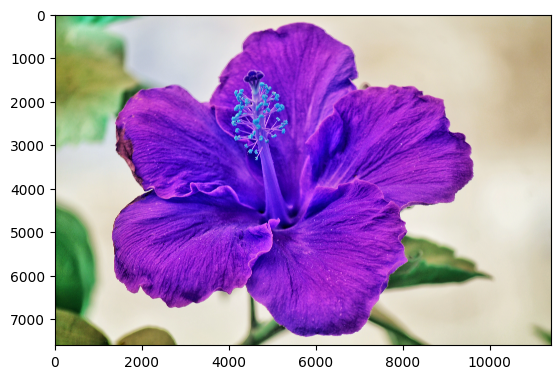

In [7]:
# resize image
up_resized = cv2.resize(image, dimension1, interpolation = cv2.INTER_AREA)

print('Upscale Resized Dimensions : ',up_resized.shape)
plt.imshow(up_resized)

The orginal image having dimension (3456, 5184, 3) is resized to  (7603, 11404, 3) using cv2.resize() function.

 - Downsampling
  - Upsampling

### 2. Do not preserve the aspect ratio




#### Resize only the height


Resized Dimensions :  (2000, 5184, 3)


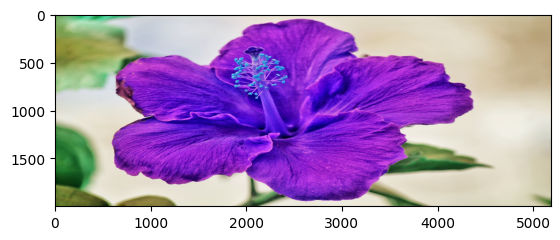

In [8]:
# keep original width
width2 = image.shape[1]
height2 = 2000
dim2 = (width2, height2)

# resize image
h_resized = cv2.resize(image, dim2, interpolation = cv2.INTER_AREA)

print('Resized Dimensions : ', h_resized.shape)
plt.imshow(h_resized)


The orginal image having dimension (3456, 5184, 3) is resized to (2000, 5184, 3) using cv2.resize() function.

#### Resize Only the height

Resized Dimensions :  (3456, 2500, 3)


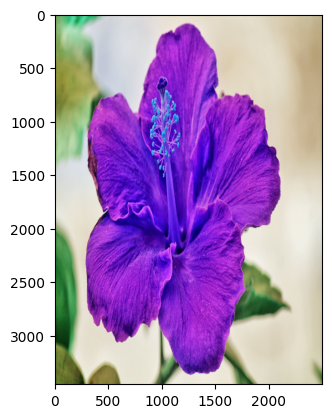

In [9]:
# keep original height

height3 = image.shape[0]
width3 = 2500
dim3 = (width3, height3)

# resize image
w_resized = cv2.resize(image, dim3, interpolation = cv2.INTER_AREA)

print('Resized Dimensions : ', w_resized.shape)
plt.imshow(w_resized)

The orginal image having dimension (3456, 5184, 3) is resized to (3456, 2500, 3) using cv2.resize() function.

#### Resize to specific Height and Weight

Resized Dimensions :  (1900, 3000, 3)


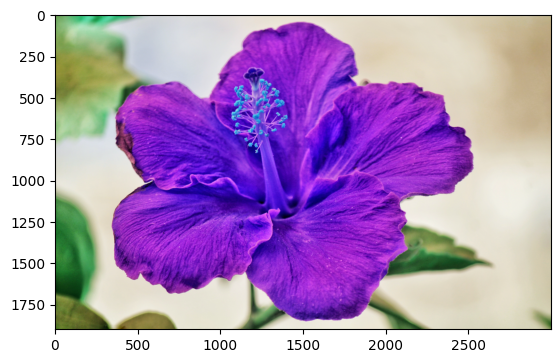

In [10]:
# resize to specific height and weight

height4 = 1900
width4 = 3000
dim4 = (width4, height4)

# resize image
hw_resized = cv2.resize(image, dim4, interpolation = cv2.INTER_AREA)

print('Resized Dimensions : ', hw_resized.shape)
plt.imshow(hw_resized)

## Upscaling by padding

Upscaling an image means making it bigger in size and shape. Padding means adding an extra layer around the image. As we resize our image to a larger size, one option may be to pad the image borders with some values. It may be "0", or "1" or values that duplicate the image content. When we resize the image by padding it with different values, our original content remains unchanged, but we are simply adding redundant information. This new information may not be useful at all.

Also, there are cases when you can resize by simply padding in between the pixels. The simplest case will be too pad with zeros. Otherwise, we have to decide on how to pad the numbers in between.



<figure>
<center>
<!-- <img src='https://doc.google.com/a/fusemachines.com/uc?export=download&id=1_tis3rE8OJcXIGVpO-jqV-S7jxn4rliV'/> -->

<img src="https://i.postimg.cc/DyxQPv5S/image.png"/>

<Figcaption> Figure 4: Image Upscaling by Zero Padding</Figcaption>
</center>
</figure>

Here you can see the upscaling using padding by zero.

Moreover, if we see the matrix representations of such padding by zero then we can see following matrix representations:


<figure>
<center>
<!-- <img src='https://doc.google.com/a/fusemachines.com/uc?export=download&id=1enh2gCTPZPxpxRFKO0CyuJKhhc_EYx8D'/> -->

<img src="https://i.postimg.cc/C5Q1dQHx/image.png/>

<Figcaption> Figure 5: Image Upscaling by Zero Padding</Figcaption>
</center>
</figure>

Here, in this matrix representation, the outer part of the matirx consists of 0 pixels. Because of this, we can see there is black patches around the cat image in Figure 4. This is not a good technique to upscale an image.



Other different techniques come into play when we are resizing the image. One such technique is an interpolation. As we resize our image, we can't fill in random values between the pixels, because we may need some information there. To address this issue, there are interpolation techniques that are used to fill the gap. We will go through each one of them and learn general ideas on producing the image's quality.

## Implementation II

### Visualization of Original, resized, padded and zero padding Image in single row.

In [11]:
# loading the images in grayscale form
img_gray = cv2.imread("sample.png", 0)
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(15, 7), dpi=80, sharex=True, sharey=True)
ax[0].imshow(img_gray, cmap="gray")
ax[0].set_title("Original")

# plotting of image with resizing
h, w = img_gray.shape
resized = cv2.resize(img_gray,(2*w, 2*h), interpolation=cv2.INTER_NEAREST)
ax[1].imshow(resized, cmap="gray")
ax[1].set_title("resized")

# plotting of image with padding
top = int(0.5 * h)
bottom = top
left = int(0.5 * w)
right = left
value = [np.random.randint(0, 255), np.random.randint(0, 255), np.random.randint(0, 255)]
padded = cv2.copyMakeBorder(img_gray, top, bottom, left, right, cv2.BORDER_REPLICATE, None, value)
ax[2].imshow(padded, cmap="gray")
ax[2].set_title("padded")
fig.show()

# plotting of image with zero padding
mask = cv2.repeat(np.array([[255, 0],[0, 0]], dtype=np.uint8), h, w)
zero_padded = cv2.bitwise_and(mask, resized)
ax[3].imshow(zero_padded, cmap="gray")
ax[3].set_title("filled with 0 padding")
fig.show()

/tmp/ipykernel_12176/1833000692.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_12176/1833000692.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


: 

Let's see the how the portion of original image, its resized form and zero padding form differs from each others.

### Showing the portion of original, resized and zero padded image in single row

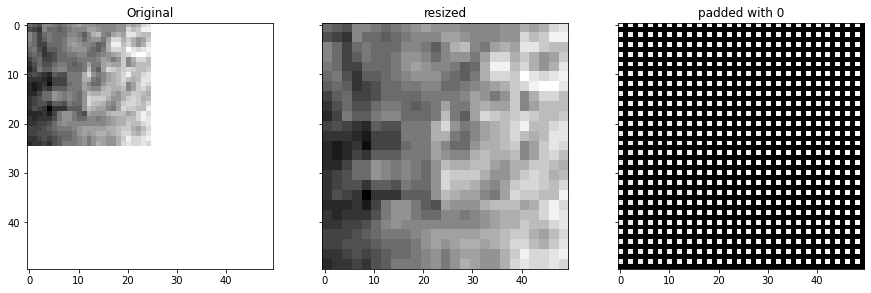

In [ ]:
# three images in a single row
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 7), sharex=True, sharey=True)

# plotting portion of original image
ax[0].imshow(img_gray[150:175, 100:125], cmap="gray")
ax[0].set_title("Original")

# plotting portion of resized image
ax[1].imshow(resized[300:350, 200:250], cmap="gray")
ax[1].set_title("resized")

# plotting portion of zero padding
ax[2].imshow(zero_padded[300:350, 200:250], cmap="gray")
ax[2].set_title("padded with 0")
fig.show()

### Showing the pixel value of original, resized and zero padded image.

#### Pixel value of original Image

original:

[[ 90  95  98  93  92]
 [ 93  99 105  99  95]
 [ 92  95 102  96  95]
 [ 86  87  93  89  93]
 [ 88  83  82  88  96]]


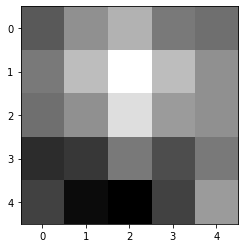

In [ ]:
# showing image portion with pixel value
print("original:\n")
x = 1500
y = 1000
part = img_gray[x:x+5, y:y+5]
print(part)
plt.imshow(part, cmap="gray")

#### Pixel value of resized Image

resized nearest:

[[ 90  90  95  95  98  98  93  93  92  92]
 [ 90  90  95  95  98  98  93  93  92  92]
 [ 93  93  99  99 105 105  99  99  95  95]
 [ 93  93  99  99 105 105  99  99  95  95]
 [ 92  92  95  95 102 102  96  96  95  95]
 [ 92  92  95  95 102 102  96  96  95  95]
 [ 86  86  87  87  93  93  89  89  93  93]
 [ 86  86  87  87  93  93  89  89  93  93]
 [ 88  88  83  83  82  82  88  88  96  96]
 [ 88  88  83  83  82  82  88  88  96  96]]


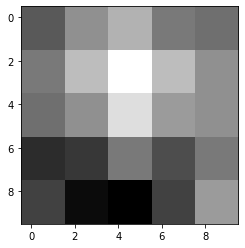

In [ ]:
# showing pixel value of resized image
print("resized nearest:\n")
part2 = resized[2*x:2*(x+5), 2*y:2*(y+5)]
print(part2)
plt.imshow(part2, cmap="gray")

#### Pixel value of zero padded Image

resized filled:

[[ 90   0  95   0  98   0  93   0  92   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [ 93   0  99   0 105   0  99   0  95   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [ 92   0  95   0 102   0  96   0  95   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [ 86   0  87   0  93   0  89   0  93   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [ 88   0  83   0  82   0  88   0  96   0]
 [  0   0   0   0   0   0   0   0   0   0]]


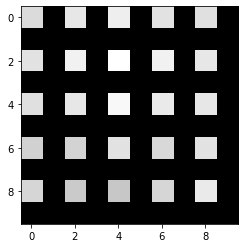

In [ ]:
# showing portion of resized image filled with zero
print("resized filled:\n")
part3 = (zero_padded[2*x:2*(x+5), 2*y:2*(y+5)])
print(part3)
plt.imshow(part3, cmap="gray")

You can see the difference when we resized without any fillings and resized with interpolation.

## Drawbacks of Resizing

*  Upscaling an image leads to loss of information, and the image looks fuzzy.
*  Downscaling does not make image fuzzy or blurry but reduces the size of the image.
*  Upscaling by padding makes image dimension larger without altering the size of its content

## Key Takeaways

* Image resolution contains the detail of the image, i.e., the number of pixels or dots.

*  Resolution is of two types:
  - Spatial resolution
  - Intensity resolution
*  Resizing of an image is simply changing the shape and size of the image.
*  Upscaling by padding means upscaling (increasing the shape and size of image) by adding padding around its borders.
*  One way to add padding is to put number $0$ around the borders called zero paddings.
*  Nearest neighbor interpolation is the type of interpolation in which the pixel value is estimated by looking at its surrounding neighbor pixels' pixel value.
*  One of the drawbacks of upscaling an image is that the image loses information and becomes fuzzier.